# ST1504 Deep Learning — CA2 Part A: Image Generation with GAN/VAE on CIFAR-10

**Module:** ST1504 Deep Learning &nbsp;|&nbsp; **Course:** DAAA &nbsp;|&nbsp; **Semester:** AY2026/27 Semester 1

**Team Members:** *Ephraim, P2510666* and *Han Qian, P2508526* and *Zheng Hao, P2510848*


In [1]:
import tensorflow as tf
tf.config.list_physical_devices()

c:\Users\ephra\anaconda3\envs\gpu_env\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [2]:
import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [3]:


from tensorflow.keras.datasets import cifar10

from tensorflow.keras.layers import Input, Dense, Reshape, Flatten, Dropout, Conv2DTranspose
from tensorflow.keras.layers import BatchNormalization, Activation, ZeroPadding2D
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import UpSampling2D, Conv2D
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt

import sys

import numpy as np


# fix random seeds for reproducibility of our experiments
np.random.seed(42)
tf.random.set_seed(42)


# Exploratory Data Analysis (EDA) & Feature Engineering

Before building any model, we examine the data. For a *generative* task the EDA focus is
different from classification: we care about **image statistics** (value ranges, colour
distribution) because they determine our **output activation / scaling choices**, and about
**intra-class visual variability** because it predicts which classes will be hard to generate.

> **Constraint (brief):** we must use `tf.keras.datasets.cifar10.load_data()` and **no external
> data**. Augmentation of the provided data is allowed *if justified and investigated*

In [4]:
(X_train, y_train), (_, _) = tf.keras.datasets.cifar10.load_data()  # CHANGED: test split discarded -- not used for training

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("X_train shape:", X_train.shape)   # expect (50000, 32, 32, 3)
print("y_train shape:", y_train.shape)   # expect (50000, 1)
print("dtype:", X_train.dtype)
print("pixel value range: min =", X_train.min(), ", max =", X_train.max())

X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
dtype: uint8
pixel value range: min = 0 , max = 255


-------------RUN ONLY FROM HERE----------------------

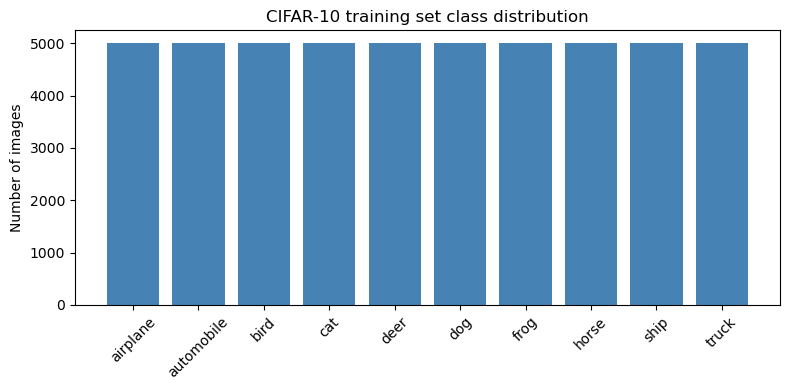

{'airplane': 5000, 'automobile': 5000, 'bird': 5000, 'cat': 5000, 'deer': 5000, 'dog': 5000, 'frog': 5000, 'horse': 5000, 'ship': 5000, 'truck': 5000}


In [5]:
# Class balance check — is any class over/under-represented?
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(8, 4))
plt.bar([class_names[u] for u in unique], counts, color='steelblue')
plt.title('CIFAR-10 training set class distribution')
plt.ylabel('Number of images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(dict(zip([class_names[u] for u in unique], counts)))

 (1) a single unconditional GAN gets equal "pressure"
from every class



 (2) the conditional GAN in Section 9 will not be biased towards any
class, so generating 100 images per class is fair.

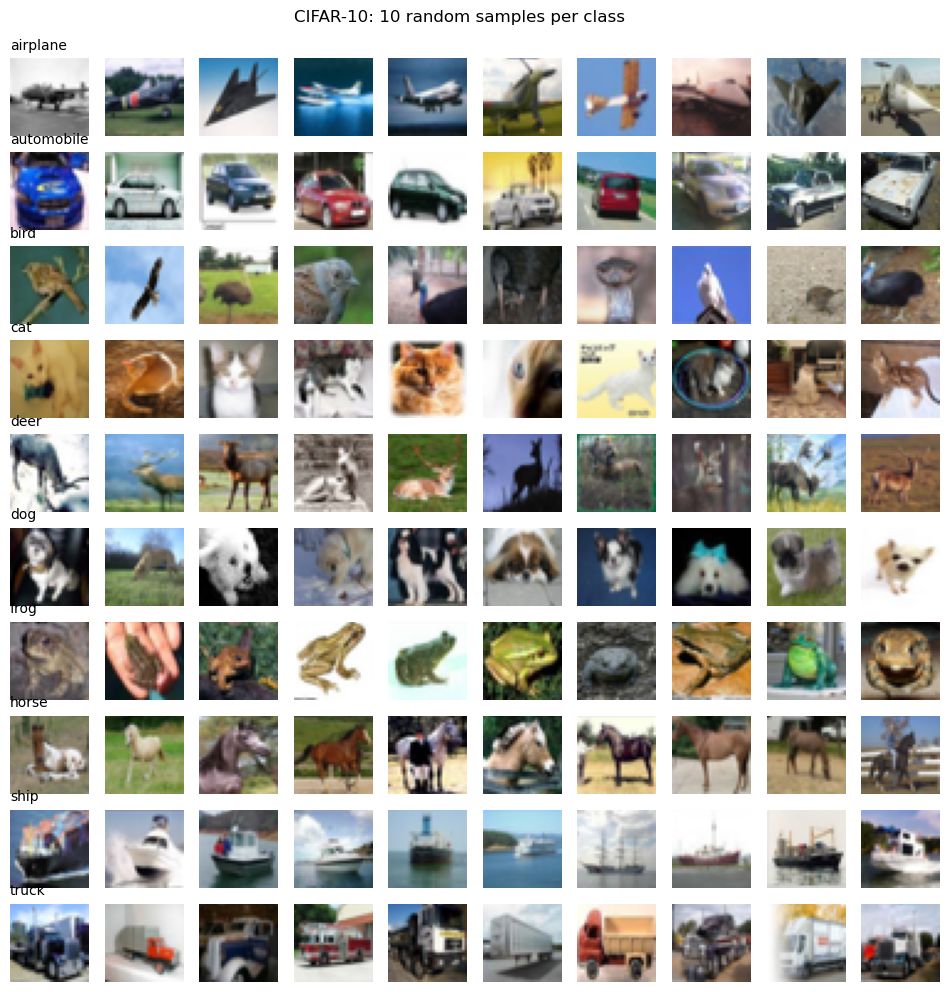

In [6]:
# Visual inspection: 10 random samples from each of the 10 classes
fig, axs = plt.subplots(10, 10, figsize=(12, 12))
for row in range(10):
    idx = np.where(y_train.flatten() == row)[0]
    chosen = np.random.choice(idx, 10, replace=False)
    for col in range(10):
        axs[row, col].imshow(X_train[chosen[col]])
        axs[row, col].axis('off')
        if col == 0:
            axs[row, col].set_title(class_names[row], loc='left', fontsize=10)
plt.suptitle('CIFAR-10: 10 random samples per class', y=0.92)
plt.show()

**Observations (fill in with your own words after running):**

- **Vehicles** (automobile, truck, ship, airplane) have rigid, box-like shapes, consistent
  orientations and often plain backgrounds (sky / sea / road) → we predict these will be
  *easier* to generate.
- **Animals** (cat, dog, bird, deer) are deformable, photographed in many poses against
  cluttered natural backgrounds → predicted *harder*.
- Many classes are roughly **left–right symmetric** (a mirrored car is still a car) →
  this motivates **horizontal-flip augmentation** in Section 8. Vertical flips would be
  invalid (an upside-down horse is not a plausible CIFAR-10 image).

These predictions are tested empirically in Section 11.

Red   channel: mean = 0.491, std = 0.247
Green channel: mean = 0.482, std = 0.243
Blue  channel: mean = 0.447, std = 0.262


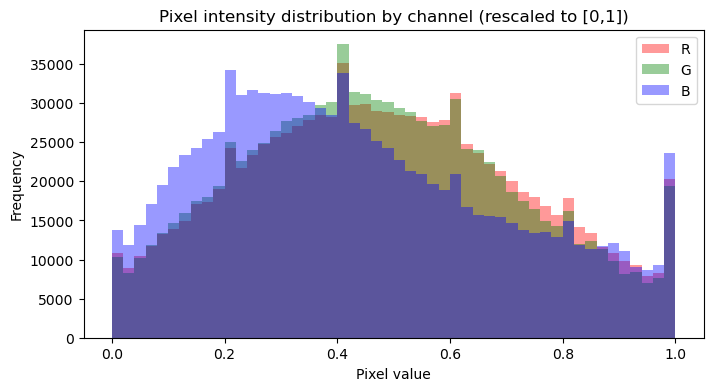

In [7]:
# Pixel intensity statistics per channel — informs output activation choice
X_float = X_train.astype('float32') / 255.0
for ch, name in enumerate(['Red', 'Green', 'Blue']):
    print(f"{name:5s} channel: mean = {X_float[:, :, :, ch].mean():.3f}, "
          f"std = {X_float[:, :, :, ch].std():.3f}")

plt.figure(figsize=(8, 4))
for ch, (name, colour) in enumerate(zip(['R', 'G', 'B'], ['red', 'green', 'blue'])):
    plt.hist(X_float[::50, :, :, ch].ravel(), bins=50, alpha=0.4, color=colour, label=name)
plt.title('Pixel intensity distribution by channel (rescaled to [0,1])')
plt.xlabel('Pixel value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

**What / why:** pixel values are spread across the whole [0, 1] range with means around
0.45–0.49 for all three channels. Two consequences:

1. A **`sigmoid`** output activation (range [0, 1]) on the generator/decoder is appropriate,
   consistent with our lab DCGAN and VAE — so we keep the lab convention of rescaling by
   `X / 255` rather than the `tanh`/[−1, 1] convention used in some papers.
2. No channel is degenerate, so we keep all 3 channels (no colour-space feature engineering
   needed). **Feature engineering** here is deliberately minimal: rescaling + (later)
   horizontal-flip augmentation. For generative modelling, aggressive feature engineering
   (e.g. normalisation per channel) would have to be *inverted* at generation time, adding
   complexity for no demonstrated benefit.

# Baseline Model

In [8]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import Input, Dense, Reshape, Flatten, Dropout
from tensorflow.keras.layers import BatchNormalization, Activation
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import UpSampling2D, Conv2D
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt


In [9]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import Input, Dense, Reshape, Flatten, Dropout
from tensorflow.keras.layers import BatchNormalization, Activation
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import UpSampling2D, Conv2D
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt
import os


class DCGAN_Baseline:
    def __init__(self, rows, cols, channels, z=100):
        self.img_rows = rows
        self.img_cols = cols
        self.channels = channels
        self.img_shape = (self.img_rows, self.img_cols, self.channels)
        self.latent_dim = z

        optimizer_d = Adam(0.0001, 0.5)
        optimizer_g = Adam(0.0002, 0.5)

        self.discriminator = self.build_discriminator()
        self.discriminator.compile(
            loss='binary_crossentropy',
            optimizer=optimizer_d,
            metrics=['accuracy'],
        )

        self.generator = self.build_generator()

        z_input = Input(shape=(self.latent_dim,))
        img = self.generator(z_input)
        self.discriminator.trainable = False
        valid = self.discriminator(img)
        self.combined = Model(z_input, valid)
        self.combined.compile(loss='binary_crossentropy', optimizer=optimizer_g)

        self.d_loss_history, self.g_loss_history, self.d_acc_history = [], [], []

        self.best_checkpoint_path = None
        self.best_epoch = None
        self.stopped_early = False
        self.collapse_epoch = None

    def build_generator(self):
        model = Sequential(name='Generator')

        model.add(Dense(256 * 4 * 4, activation="relu", input_dim=self.latent_dim))
        model.add(Reshape((4, 4, 256)))
        model.add(BatchNormalization(momentum=0.8))
        model.add(Activation("relu"))

        model.add(UpSampling2D())
        model.add(Conv2D(256, kernel_size=3, padding="same"))
        model.add(BatchNormalization(momentum=0.8))
        model.add(Activation("relu"))

        model.add(UpSampling2D())
        model.add(Conv2D(128, kernel_size=3, padding="same"))
        model.add(BatchNormalization(momentum=0.8))
        model.add(Activation("relu"))

        model.add(UpSampling2D())
        model.add(Conv2D(64, kernel_size=3, padding="same"))
        model.add(BatchNormalization(momentum=0.8))
        model.add(Activation("relu"))

        model.add(Conv2D(self.channels, kernel_size=3, padding="same"))
        model.add(Activation("tanh"))

        model.summary()
        noise = Input(shape=(self.latent_dim,))
        img = model(noise)
        return Model(noise, img)

    def build_discriminator(self):
        model = Sequential(name='Discriminator')

        model.add(Conv2D(64, kernel_size=3, strides=2, input_shape=self.img_shape, padding="same"))
        model.add(LeakyReLU(alpha=0.2))

        model.add(Conv2D(128, kernel_size=3, strides=2, padding="same"))
        model.add(BatchNormalization(momentum=0.8))
        model.add(LeakyReLU(alpha=0.2))

        model.add(Conv2D(256, kernel_size=3, strides=2, padding="same"))
        model.add(BatchNormalization(momentum=0.8))
        model.add(LeakyReLU(alpha=0.2))
        model.add(Dropout(0.25))

        model.add(Flatten())
        model.add(Dropout(0.25))
        model.add(Dense(1, activation='sigmoid'))

        model.summary()
        img = Input(shape=self.img_shape)
        validity = model(img)
        return Model(img, validity)

    def train(self, epochs, batch_size=128, save_interval=10,
              out_dir='generated_cifar10_baseline_fixed', weights_dir='weights',
              min_epoch_before_stop=15, stuck_streak_limit=5):
        os.makedirs(out_dir, exist_ok=True)
        os.makedirs(weights_dir, exist_ok=True)

        (X_train, _), (X_test, _) = cifar10.load_data()
        X_train = np.concatenate([X_train, X_test], axis=0)
        X_train = X_train.astype('float32') / 127.5 - 1.

        batches_per_epoch = X_train.shape[0] // batch_size

        valid = np.ones((batch_size, 1)) * 0.9
        fake = np.zeros((batch_size, 1))
        valid_g = np.ones((batch_size, 1))

        stuck_streak = 0

        for epoch in range(epochs):
            for _ in range(batches_per_epoch):
                idx = np.random.randint(0, X_train.shape[0], batch_size)
                imgs = X_train[idx]

                noise = np.random.normal(0, 1, (batch_size, self.latent_dim))
                gen_imgs = self.generator(noise, training=False).numpy()

                d_loss_real = self.discriminator.train_on_batch(imgs, valid)
                d_loss_fake = self.discriminator.train_on_batch(gen_imgs, fake)
                d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

                g_loss = self.combined.train_on_batch(noise, valid_g)

            self.d_loss_history.append(d_loss[0])
            self.g_loss_history.append(g_loss)
            self.d_acc_history.append(d_loss[1])

            print("epoch %d/%d [D loss: %f, acc.: %.2f%%] [G loss: %f]"
                  % (epoch, epochs, d_loss[0], 100 * d_loss[1], g_loss))

            is_pinned = abs(d_loss[1] - 0.5) < 1e-9
            stuck_streak = stuck_streak + 1 if is_pinned else 0

            do_periodic_save = (epoch % save_interval == 0 or epoch == epochs - 1)

            if do_periodic_save:
                gen_path = os.path.join(weights_dir, f'dcgan_baseline_fixed_gen_epoch{epoch}.h5')
                self.save_imgs(epoch, out_dir)
                self.generator.save_weights(gen_path)
                if stuck_streak == 0:
                    self.best_checkpoint_path = gen_path
                    self.best_epoch = epoch

            if stuck_streak == stuck_streak_limit and epoch >= min_epoch_before_stop:
                self.collapse_epoch = epoch - stuck_streak_limit + 1
                print(f"  COLLAPSE DETECTED: d_acc pinned at 50.00% since ~epoch "
                      f"{self.collapse_epoch}. Stopping early at epoch {epoch}.")
                self.stopped_early = True
                break

        if self.stopped_early and self.best_checkpoint_path is not None:
            print(f"  Restoring generator to epoch {self.best_epoch} "
                  f"({self.best_checkpoint_path}) -- last checkpoint before collapse.")
            self.generator.load_weights(self.best_checkpoint_path)

            best_path = os.path.join(weights_dir, 'dcgan_baseline_fixed_gen_BEST.h5')
            self.generator.save_weights(best_path)
            self.save_imgs('BEST', out_dir)
            print(f"  Best generator saved to {best_path}, "
                  f"sample grid saved to {out_dir}/dcgan_baseline_fixed_BEST.png")
        elif not self.stopped_early:
            print(f"  Training completed all {epochs} epochs without collapsing. "
                  f"Best checkpoint on record: epoch {self.best_epoch}.")

    def save_imgs(self, epoch, out_dir):
        r, c = 5, 5
        noise = np.random.normal(0, 1, (r * c, self.latent_dim))
        gen_imgs = self.generator(noise, training=False).numpy()
        gen_imgs = 0.5 * gen_imgs + 0.5

        fig, axs = plt.subplots(r, c)
        cnt = 0
        for i in range(r):
            for j in range(c):
                axs[i, j].imshow(gen_imgs[cnt])
                axs[i, j].axis('off')
                cnt += 1
        fig.savefig(os.path.join(out_dir, f"dcgan_baseline_fixed_{epoch}.png"))
        plt.close()

    def plot_losses(self, title='Baseline (fixed) DCGAN training losses'):
        fig, axs = plt.subplots(1, 2, figsize=(12, 4))
        axs[0].plot(self.d_loss_history, label='Discriminator loss', alpha=0.7)
        axs[0].plot(self.g_loss_history, label='Generator loss', alpha=0.7)
        if self.collapse_epoch is not None:
            axs[0].axvline(self.collapse_epoch, color='red', linestyle='--',
                            alpha=0.5, label='collapse onset')
        axs[0].set_xlabel('Epoch'); axs[0].set_ylabel('Loss'); axs[0].legend()
        axs[0].set_title(title)
        axs[1].plot(self.d_acc_history, color='green', alpha=0.7)
        axs[1].axhspan(0.5, 0.8, color='green', alpha=0.1)
        if self.collapse_epoch is not None:
            axs[1].axvline(self.collapse_epoch, color='red', linestyle='--', alpha=0.5)
        axs[1].set_xlabel('Epoch'); axs[1].set_ylabel('Discriminator accuracy')
        axs[1].set_title('Discriminator accuracy (healthy zone ~ 0.5-0.8)')
        plt.show()


# dcgan = DCGAN_Baseline(32, 32, 3)
# dcgan.train(epochs=100, batch_size=128, save_interval=10)
# dcgan.plot_losses()

In [10]:
dcgan = DCGAN(32, 32, 3)
dcgan.train(epochs=100, batch_size=128, save_interval=20)
dcgan.plot_losses('Baseline DCGAN on CIFAR-10')


NameError: name 'DCGAN' is not defined

# Strong DCGAN (best-practice, separate model)

Combines every standard DCGAN stabilization trick in one model: deeper 4x4 seed, BatchNorm placed per the original DCGAN paper guidelines (skipped on the discriminator's first conv and the generator's output layer), one-sided label smoothing, and a slower discriminator learning rate than the generator. This still needs many thousands of iterations to look decent -- CIFAR-10 is a hard, diverse 32x32 colour dataset, so don't expect photo-realism, just clearer/more coherent shapes than the baseline given enough training.

# Max-Tuned DCGAN (nested loop, true 100 epochs)

True epochs this time (100 full passes over all 60,000 images via a nested loop), combined with every reasonable anti-discriminator-dominance trick stacked together: one-sided label smoothing, a discriminator learning rate 4x slower than the generator's, two generator updates per discriminator update, instance noise on the discriminator's inputs, and extra dropout throughout the discriminator. This will take a long time to run -- ~46,800 total training steps.

In [ ]:
class DCGAN_MaxTuned():
    def __init__(self, rows, cols, channels, z=100):
        self.img_rows = rows
        self.img_cols = cols
        self.channels = channels
        self.img_shape = (self.img_rows, self.img_cols, self.channels)
        self.latent_dim = z

        # Discriminator learns 4x slower than the generator (0.00005 vs 0.0002) --
        # more aggressive than DCGAN_Strong's 2x gap, since that still wasn't enough
        # to stop the discriminator eventually dominating by iteration 20,000.
        optimizer_d = Adam(0.00005, 0.5)
        optimizer_g = Adam(0.0002, 0.5)

        self.discriminator = self.build_discriminator()
        self.discriminator.compile(loss='binary_crossentropy',
            optimizer=optimizer_d,
            metrics=['accuracy'])

        self.generator = self.build_generator()

        z_input = Input(shape=(self.latent_dim,))
        img = self.generator(z_input)
        self.discriminator.trainable = False
        valid = self.discriminator(img)
        self.combined = Model(z_input, valid)
        self.combined.compile(loss='binary_crossentropy', optimizer=optimizer_g)

        self.d_loss_history, self.g_loss_history, self.d_acc_history = [], [], []

    def build_generator(self):
        model = Sequential(name='Generator')

        model.add(Dense(256 * 4 * 4, activation="relu", input_dim=self.latent_dim))
        model.add(Reshape((4, 4, 256)))
        model.add(BatchNormalization(momentum=0.8))
        model.add(Activation("relu"))

        model.add(UpSampling2D())  # 4x4 -> 8x8
        model.add(Conv2D(256, kernel_size=4, padding="same"))
        model.add(BatchNormalization(momentum=0.8))
        model.add(Activation("relu"))

        model.add(UpSampling2D())  # 8x8 -> 16x16
        model.add(Conv2D(128, kernel_size=4, padding="same"))
        model.add(BatchNormalization(momentum=0.8))
        model.add(Activation("relu"))

        model.add(UpSampling2D())  # 16x16 -> 32x32
        model.add(Conv2D(64, kernel_size=4, padding="same"))
        model.add(BatchNormalization(momentum=0.8))
        model.add(Activation("relu"))

        model.add(Conv2D(self.channels, kernel_size=4, padding="same"))  # no BatchNorm on the output layer
        model.add(Activation("tanh"))

        model.summary()
        noise = Input(shape=(self.latent_dim,))
        img = model(noise)
        return Model(noise, img)

    def build_discriminator(self):
        model = Sequential(name='Discriminator')

        # No BatchNorm on the first layer (DCGAN guideline), but extra Dropout throughout
        # to weaken the discriminator further -- on top of label smoothing and the slow LR.
        model.add(Conv2D(64, kernel_size=3, strides=2, input_shape=self.img_shape, padding="same"))
        model.add(LeakyReLU(alpha=0.2))
        model.add(Dropout(0.3))

        model.add(Conv2D(128, kernel_size=3, strides=2, padding="same"))
        model.add(BatchNormalization(momentum=0.8))
        model.add(LeakyReLU(alpha=0.2))
        model.add(Dropout(0.3))

        model.add(Conv2D(256, kernel_size=3, strides=2, padding="same"))
        model.add(BatchNormalization(momentum=0.8))
        model.add(LeakyReLU(alpha=0.2))
        model.add(Dropout(0.3))

        model.add(Flatten())
        model.add(Dropout(0.4))
        model.add(Dense(1, activation='sigmoid'))

        model.summary()
        img = Input(shape=self.img_shape)
        validity = model(img)
        return Model(img, validity)

    def train(self, epochs, batch_size=128, save_interval=10, noise_std=0.05):
        (X_train, _), (X_test, _) = cifar10.load_data()
        X_train = np.concatenate([X_train, X_test], axis=0)  # all 60,000 images
        X_train = X_train.astype('float32') / 127.5 - 1.  # rescale -1 to 1 (matches tanh output)

        # Nested loop -- one true epoch = one full pass over all 60,000 images
        batches_per_epoch = X_train.shape[0] // batch_size

        valid = np.ones((batch_size, 1)) * 0.9   # one-sided label smoothing
        fake = np.zeros((batch_size, 1))
        valid_g = np.ones((batch_size, 1))       # generator's target stays a full 1.0

        for epoch in range(epochs):
            for batch_i in range(batches_per_epoch):
                idx = np.random.randint(0, X_train.shape[0], batch_size)
                imgs = X_train[idx]

                noise = np.random.normal(0, 1, (batch_size, self.latent_dim))
                gen_imgs = self.generator(noise, training=False).numpy()  # direct call, avoids .predict() memory leak

                # Instance noise: small Gaussian noise added to both real and fake images
                # before the discriminator sees them -- blurs the real/fake boundary early
                # on, buying the generator more time before the discriminator gets too sharp.
                imgs_noisy = imgs + np.random.normal(0, noise_std, imgs.shape)
                gen_imgs_noisy = gen_imgs + np.random.normal(0, noise_std, gen_imgs.shape)

                d_loss_real = self.discriminator.train_on_batch(imgs_noisy, valid)
                d_loss_fake = self.discriminator.train_on_batch(gen_imgs_noisy, fake)
                d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

                # Two generator updates per discriminator update -- gives the generator
                # extra learning steps relative to the discriminator each iteration.
                g_loss = self.combined.train_on_batch(noise, valid_g)
                noise2 = np.random.normal(0, 1, (batch_size, self.latent_dim))
                g_loss = self.combined.train_on_batch(noise2, valid_g)

                self.d_loss_history.append(d_loss[0])
                self.g_loss_history.append(g_loss)
                self.d_acc_history.append(d_loss[1])

            print ("epoch %d/%d [D loss: %f, acc.: %.2f%%] [G loss: %f]" % (epoch, epochs, d_loss[0], 100*d_loss[1], g_loss))

            if epoch % save_interval == 0 or epoch == epochs - 1:
                self.save_imgs(epoch)

    def save_imgs(self, epoch):
        r, c = 5, 5
        noise = np.random.normal(0, 1, (r * c, self.latent_dim))
        gen_imgs = self.generator(noise, training=False).numpy()
        gen_imgs = 0.5 * gen_imgs + 0.5  # rescale -1..1 -> 0..1 for display

        fig, axs = plt.subplots(r, c)
        cnt = 0
        for i in range(r):
            for j in range(c):
                axs[i,j].imshow(gen_imgs[cnt])
                axs[i,j].axis('off')
                cnt += 1
        fig.savefig("generated_cifar10_maxtuned/dcgan_maxtuned_{:d}.png".format(epoch))
        plt.close()

    def plot_losses(self, title='Max-Tuned DCGAN training losses'):
        fig, axs = plt.subplots(1, 2, figsize=(12, 4))
        axs[0].plot(self.d_loss_history, label='Discriminator loss', alpha=0.7)
        axs[0].plot(self.g_loss_history, label='Generator loss', alpha=0.7)
        axs[0].set_xlabel('Iteration'); axs[0].set_ylabel('Loss'); axs[0].legend()
        axs[0].set_title(title)
        axs[1].plot(self.d_acc_history, color='green', alpha=0.7)
        axs[1].set_xlabel('Iteration'); axs[1].set_ylabel('Discriminator accuracy')
        axs[1].set_title('Discriminator accuracy (healthy zone ~ 0.5-0.8)')
        plt.show()


Model: "Discriminator"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_126 (Conv2D)         (None, 16, 16, 64)        1792      
                                                                 
 leaky_re_lu_63 (LeakyReLU)  (None, 16, 16, 64)        0         
                                                                 
 dropout_66 (Dropout)        (None, 16, 16, 64)        0         
                                                                 
 conv2d_127 (Conv2D)         (None, 8, 8, 128)         73856     
                                                                 
 batch_normalization_99 (Bat  (None, 8, 8, 128)        512       
 chNormalization)                                                
                                                                 
 leaky_re_lu_64 (LeakyReLU)  (None, 8, 8, 128)         0         
                                                     

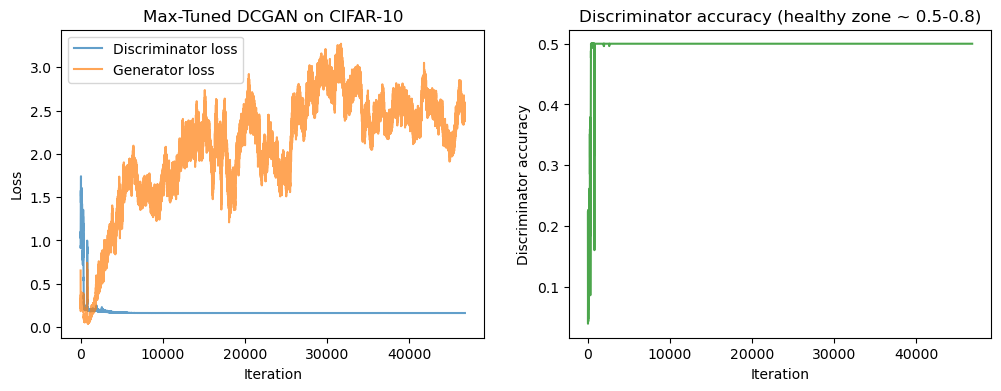

In [ ]:
import os
os.makedirs('generated_cifar10_maxtuned', exist_ok=True)

dcgan_maxtuned = DCGAN_MaxTuned(32, 32, 3)
# 100 TRUE epochs (nested loop) -- ~46,800 total training steps, will take a long time
dcgan_maxtuned.train(epochs=100, batch_size=128, save_interval=10)
dcgan_maxtuned.plot_losses('Max-Tuned DCGAN on CIFAR-10')
